<a href="https://colab.research.google.com/github/ZonaE03/Inteligencia_Artificial_2026/blob/main/Actividades/Actividad_5_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving robot_sensors.csv to robot_sensors (2).csv


In [ ]:
df = pd.read_csv("robot_sensors.csv")

print(df.head(30))

    Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
0            0       43.708611          9.256646         23.925585
1            1       95.564288         27.095047         23.704682
2            2       75.879455         43.647292         33.593819
3            3       63.879264         36.611244         23.743193
4            4       24.041678         40.328057         24.079246
5            5       24.039507         32.939168         31.390974
6            6       15.227525         34.613828         26.746098
7            7       87.955853         42.459783         31.650658
8            8       64.100351         12.483400         20.980492
9            9       73.726532         24.471248         27.313568
10          10       11.852604         11.060472         20.504204
11          11       97.291887         49.383400         20.939798
12          12       84.919838         47.202967         33.596562
13          13       29.110520          1.971341         22.08

In [ ]:
#Obtener el tipo de informacion de las columnas
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Tiempo (s)        1000 non-null   int64  
 1   Distancia (cm)    970 non-null    float64
 2   Velocidad (cm/s)  970 non-null    float64
 3   Temperatura (°C)  970 non-null    float64
dtypes: float64(3), int64(1)
memory usage: 31.4 KB
None


In [ ]:
#¿cuantas propiedades hay en total en el conujunto de datos?
print(df.shape)   #Utiliza el metodo shape para obtener la informacion

(1000, 4)


In [ ]:
# Verificamos si existen valores nulos (missing values) en alguna columna y como manejarlo
# Utilizamos isnull() y sum() para identificar valores nulos
print(df.isnull().sum())

Tiempo (s)           0
Distancia (cm)      30
Velocidad (cm/s)    30
Temperatura (°C)    30
dtype: int64


In [ ]:
# Si encuentras valores nulos, puedes optar por rellenarlos con la media o eliminar las filas con datos faltantes
df['Distancia (cm)'] = df['Distancia (cm)'].fillna(df['Distancia (cm)'].mean())
df['Velocidad (cm/s)'] = df['Velocidad (cm/s)'].fillna(df['Velocidad (cm/s)'].mean())
df['Temperatura (°C)'] = df['Temperatura (°C)'].fillna(df['Temperatura (°C)'].mean())

print(df.isnull().sum())

Tiempo (s)          0
Distancia (cm)      0
Velocidad (cm/s)    0
Temperatura (°C)    0
dtype: int64


In [ ]:
# Filtraremos valores atipicos, como es el caso de la velocidad lenta
df_velocidad_lenta = df[df['Velocidad (cm/s)'] < 5]
print(df_velocidad_lenta)

     Tiempo (s)  Distancia (cm)  Velocidad (cm/s)  Temperatura (°C)
13           13       29.110520          1.971341         22.088681
19           19       36.210623          1.697299         29.956845
30           30       64.679037          1.850382         22.971464
34           34       96.906883          3.847660         29.127909
38           38       71.580972          3.267817         23.379754
..          ...             ...               ...               ...
969         969       52.844536          1.309835         27.443881
970         970       69.730405          1.209588         25.707766
985         985       54.594218          4.030076         34.505529
997         997       22.313677          3.447901         24.646818
998         998       95.521362          2.852736         24.350683

[107 rows x 4 columns]


In [ ]:
# Normalizamos los datos de las columnas
df['Distancia_normalizada'] = (df['Distancia (cm)'] - df['Distancia (cm)'].min()) / (df['Distancia (cm)'].max() - df['Distancia (cm)'].min())
df['Velocidad_normalizada'] = (df['Velocidad (cm/s)'] - df['Velocidad (cm/s)'].min()) / (df['Velocidad (cm/s)'].max() - df['Velocidad (cm/s)'].min())
df['Temperatura_normalizada'] = (df['Temperatura (°C)'] - df['Temperatura (°C)'].min()) / (df['Temperatura (°C)'].max() - df['Temperatura (°C)'].min())
df['Tiempo_normalizado'] = (df['Tiempo (s)'] - df['Tiempo (s)'].min()) / (df['Tiempo (s)'].max() - df['Tiempo (s)'].min())

In [ ]:
# visualizamos la temperatura más alta y mas baja
temperatura_max = df.loc[df['Temperatura (°C)'].idxmax()]
temperatura_min = df.loc[df['Temperatura (°C)'].idxmin()]

print(temperatura_max)
print(temperatura_min)

Tiempo (s)                 529.000000
Distancia (cm)              87.825014
Velocidad (cm/s)            26.958064
Temperatura (°C)            34.967313
Distancia_normalizada        0.864338
Velocidad_normalizada        0.537990
Temperatura_normalizada      1.000000
Tiempo_normalizado           0.529530
Name: 529, dtype: float64
Tiempo (s)                 902.000000
Distancia (cm)              26.329189
Velocidad (cm/s)            38.049538
Temperatura (°C)            20.000175
Distancia_normalizada        0.177677
Velocidad_normalizada        0.760666
Temperatura_normalizada      0.000000
Tiempo_normalizado           0.902903
Name: 902, dtype: float64


In [ ]:
# Visualizamos la velocidad más alta y más baja
velocidad_max = df.loc[df['Velocidad (cm/s)'].idxmax()]
velocidad_min = df.loc[df['Velocidad (cm/s)'].idxmin()]
print(velocidad_max)
print(velocidad_min)

Tiempo (s)                 464.000000
Distancia (cm)              96.595529
Velocidad (cm/s)            49.970686
Temperatura (°C)            29.309907
Distancia_normalizada        0.962269
Velocidad_normalizada        1.000000
Temperatura_normalizada      0.622012
Tiempo_normalizado           0.464464
Name: 464, dtype: float64
Tiempo (s)                 921.000000
Distancia (cm)              53.868808
Velocidad (cm/s)             0.160913
Temperatura (°C)            30.689320
Distancia_normalizada        0.485184
Velocidad_normalizada        0.000000
Temperatura_normalizada      0.714174
Tiempo_normalizado           0.921922
Name: 921, dtype: float64


In [ ]:
# Visualizamos el tiempo más alto y más bajo
tiempo_max = df.loc[df['Tiempo (s)'].idxmax()]
tiempo_min = df.loc[df['Tiempo (s)'].idxmin()]
print(tiempo_max)
print(tiempo_min)

Tiempo (s)                 999.000000
Distancia (cm)              50.140520
Velocidad (cm/s)            14.109354
Temperatura (°C)            33.071211
Distancia_normalizada        0.443554
Velocidad_normalizada        0.280034
Temperatura_normalizada      0.873316
Tiempo_normalizado           1.000000
Name: 999, dtype: float64
Tiempo (s)                  0.000000
Distancia (cm)             43.708611
Velocidad (cm/s)            9.256646
Temperatura (°C)           23.925585
Distancia_normalizada       0.371735
Velocidad_normalizada       0.182609
Temperatura_normalizada     0.262269
Tiempo_normalizado          0.000000
Name: 0, dtype: float64


In [ ]:
# Visualizamos la distancia más alta y más baja
distancia_max = df.loc[df['Distancia (cm)'].idxmax()]
distancia_min = df.loc[df['Distancia (cm)'].idxmin()]
print(distancia_max)
print(distancia_min)

Tiempo (s)                 531.000000
Distancia (cm)              99.974591
Velocidad (cm/s)            30.516689
Temperatura (°C)            32.427039
Distancia_normalizada        1.000000
Velocidad_normalizada        0.609434
Temperatura_normalizada      0.830277
Tiempo_normalizado           0.531532
Name: 531, dtype: float64
Tiempo (s)                 821.000000
Distancia (cm)              10.416882
Velocidad (cm/s)             6.069321
Temperatura (°C)            23.430152
Distancia_normalizada        0.000000
Velocidad_normalizada        0.118619
Temperatura_normalizada      0.229167
Tiempo_normalizado           0.821822
Name: 821, dtype: float64


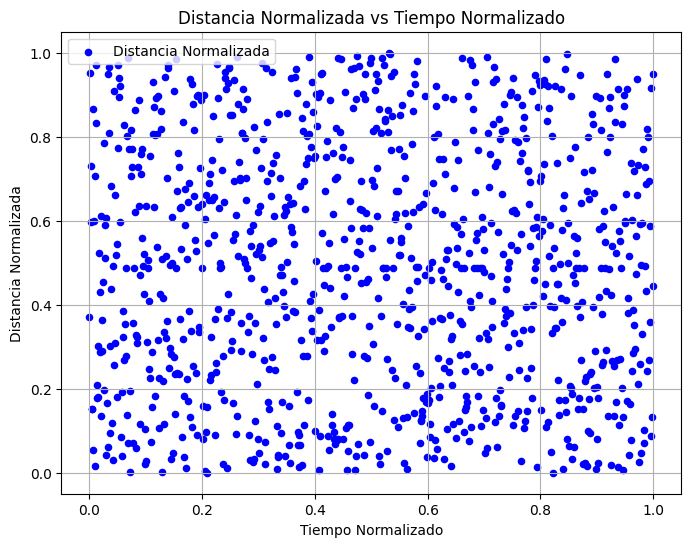

In [ ]:
# Con los valores normalizados de las columnas crearemos una grafica de dispersión 'Tiempo_normalizado' y 'Distancia_normalizada'
plt.figure(figsize=(8, 6))
plt.scatter(df['Tiempo_normalizado'], df['Distancia_normalizada'], label='Distancia Normalizada', marker='o', s=20, c='blue')

plt.xlabel('Tiempo Normalizado')
plt.ylabel('Distancia Normalizada')
plt.title('Distancia Normalizada vs Tiempo Normalizado')
plt.legend()
plt.grid(True)

plt.show()

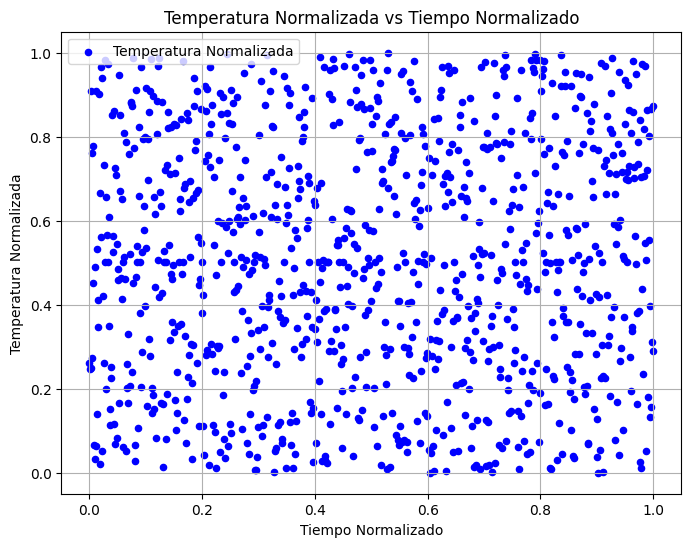

In [ ]:
# Con los valores normalizados de las columnas crearemos una grafica de dispersión 'Tiempo_normalizado' y 'Temperatura_normalizada'
plt.figure(figsize=(8, 6))
plt.scatter(df['Tiempo_normalizado'], df['Temperatura_normalizada'], label='Temperatura Normalizada', marker='o', s=20, c='blue')

plt.xlabel('Tiempo Normalizado')
plt.ylabel('Temperatura Normalizada')
plt.title('Temperatura Normalizada vs Tiempo Normalizado')
plt.legend()
plt.grid(True)

plt.show()

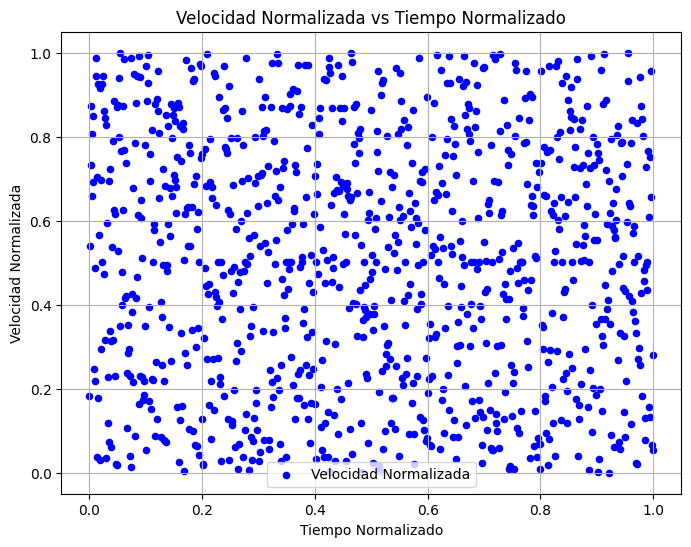

In [ ]:
# Con los valores normalizados de las columnas crearemos una grafica de dispersión 'Tiempo_normalizado' y 'Velocidad_normalizada'
plt.figure(figsize=(8, 6))
plt.scatter(df['Tiempo_normalizado'], df['Velocidad_normalizada'], label='Velocidad Normalizada', marker='o', s=20, c='blue')

plt.xlabel('Tiempo Normalizado')
plt.ylabel('Velocidad Normalizada')
plt.title('Velocidad Normalizada vs Tiempo Normalizado')
plt.legend()
plt.grid(True)

plt.show()